## Classification Analysis - FIFA 23 Players

Σε αυτό το notebook εφαρμόζεται ταξινόμηση (classification) σε δεδομένα παικτών από το FIFA 23.

Ο στόχος είναι να προβλέψουμε την καλύτερη θέση ενός παίκτη (`best_position`) με βάση τα χαρακτηριστικά του, όπως ηλικία, ύψος, overall rating, pace, shooting, passing, defending, physicality και άλλα τεχνικά attributes.

Η ταξινόμηση χρησιμοποιείται όταν η μεταβλητή που θέλουμε να προβλέψουμε είναι κατηγορική. Στη συγκεκριμένη περίπτωση, το `best_position` περιέχει κατηγορίες θέσεων όπως ST, CM, CB, GK, RW και άλλες.

In [60]:
# Βασικές βιβλιοθήκες για επεξεργασία δεδομένων
import pandas as pd
import numpy as np

# Βιβλιοθήκη για γραφήματα
import matplotlib.pyplot as plt

# Εργαλεία για διαχωρισμό και επεξεργασία δεδομένων
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Αλγόριθμοι ταξινόμησης
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Metrics για αξιολόγηση classification μοντέλων
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Για να εμφανίζονται τα γραφήματα μέσα στο notebook
%matplotlib inline

## 1. Loading the Dataset

Σε αυτό το βήμα φορτώνουμε το FIFA 23 players dataset.

Το dataset περιέχει πληροφορίες για ποδοσφαιριστές, όπως ηλικία, ύψος, βάρος, overall rating, potential, τεχνικά χαρακτηριστικά και καλύτερη θέση παίκτη.

## 2. Loading and Description of Dataset

In [61]:
# Φόρτωση του dataset
df = pd.read_csv('data/fifa23_players_clean.csv')
df.head() # Βλέπουμε τις 5 πρώτες γραμμές του dataset

,id,name,full_name,age,height,weight,photo_url,nationality,overall,potential,...,lm_rating,cm_rating,rm_rating,lwb_rating,cdm_rating,rwb_rating,lb_rating,cb_rating,rb_rating,gk_rating
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,91,87,91,67,65,67,62,53,62,22
1,165153,K. Benzema,Karim Benzema,34,187,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,89,84,89,67,67,67,63,58,63,21
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,86,83,86,67,69,67,64,63,64,22
3,190871,Neymar Jr,Neymar da Silva Santos Jr.,30,175,68,https://cdn.sofifa.net/players/190/871/23_60.png,Brazil,91,91,...,91,85,91,69,66,69,65,54,65,23
4,192119,T. Courtois,Thibaut Courtois,30,199,96,https://cdn.sofifa.net/players/192/119/23_60.png,Belgium,91,92,...,34,36,34,32,34,32,32,32,32,91


In [62]:
# Βασικές πληροφορίες στηλών και τύπων δεδομένων
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 82 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   1221 non-null   int64 
 1   name                 1221 non-null   object
 2   full_name            1221 non-null   object
 3   age                  1221 non-null   int64 
 4   height               1221 non-null   int64 
 5   weight               1221 non-null   int64 
 6   photo_url            1221 non-null   object
 7   nationality          1221 non-null   object
 8   overall              1221 non-null   int64 
 9   potential            1221 non-null   int64 
 10  growth               1221 non-null   int64 
 11  total_stats          1221 non-null   int64 
 12  base_stats           1221 non-null   int64 
 13  positions            1221 non-null   object
 14  best_position        1221 non-null   object
 15  club                 1221 non-null   object
 16  nation

In [63]:
#Ονόματα στηλών
df.columns 

Index(['id', 'name', 'full_name', 'age', 'height', 'weight', 'photo_url',
       'nationality', 'overall', 'potential', 'growth', 'total_stats',
       'base_stats', 'positions', 'best_position', 'club', 'national_team',
       'national_position', 'national_number', 'preferred_foot',
       'int_reputation', 'weak_foot', 'skill_moves', 'attacking_work_rate',
       'defensive_work_rate', 'pace_total', 'shooting_total', 'passing_total',
       'dribbling_total', 'defending_total', 'physicality_total', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'fk_accuracy', 'long_passing', 'ball_control',
       'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance',
       'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', '

In [64]:
print("Μέγεθος dataset:", df.shape)

Μέγεθος dataset: (1221, 82)


In [65]:
# Η Ταξινόμηση θέλει κατηγορική μεταβλητή
# Η στήλη 'best_position' είναι κατάλληλη επειδή μας δείχνει την καλύτερη θέση κάθε παίκτη

df['best_position'].describe()  # Βλέπουμε βασικές πληροφορίες για τη στήλη

count     1221
unique      15
top         CB
freq       236
Name: best_position, dtype: object

In [66]:
# Ελέγχουμε ποιες στήλες έχουν κενές τιμές

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("Δεν υπάρχουν κενές τιμές στο dataset.")
else:
    print("Στήλες με κενές τιμές:")
    print(missing_values)

Δεν υπάρχουν κενές τιμές στο dataset.


In [67]:
# Ελέγχουμε αν υπάρχουν κενές τιμές στη μεταβλητή που θέλουμε να προβλέψουμε

df['best_position'].isnull().sum()
print(f"Οι κενές τιμές στην target στήλη είναι: {df['best_position'].isnull().sum()}")

Οι κενές τιμές στην target στήλη είναι: 0


## 3.Exploratory Data Analysis (EDA)

In [30]:
# Μετράμε πόσοι παίκτες υπάρχουν σε κάθε θέση

position_counts = df['best_position'].value_counts()

position_counts

best_position
CB     236
ST     148
GK     143
CAM    142
CM     107
CDM     95
RM      70
RB      59
LM      52
LB      41
RWB     35
LWB     30
RW      23
LW      23
CF      17
Name: count, dtype: int64

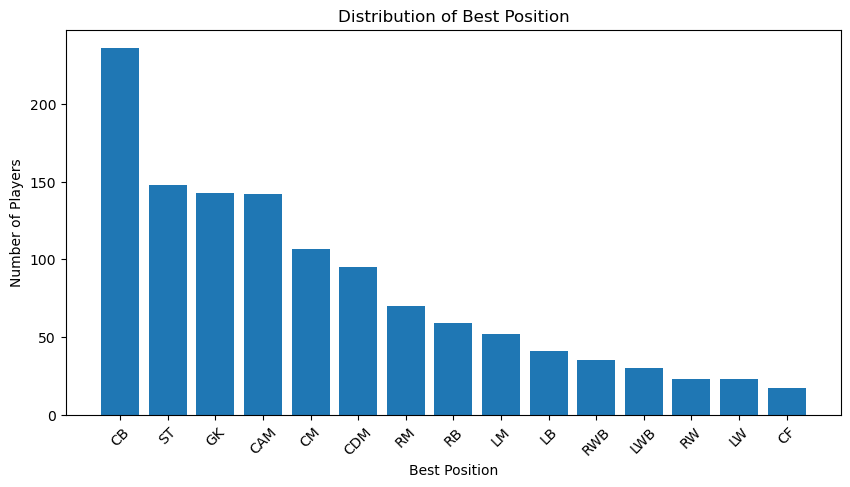

In [ ]:
# Bar Chart για την κατανομή των θέσεων

plt.figure(figsize=(10, 5))

plt.bar(position_counts.index, position_counts.values)

plt.title('Distribution of Best Position')
plt.xlabel('Best Position')
plt.ylabel('Number of Players')

plt.xticks(rotation=45)

plt.show()

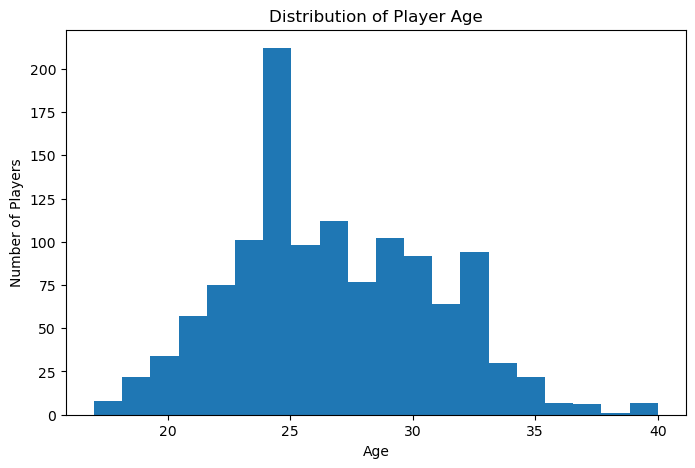

In [ ]:
# Histogram για την κατανομή της ηλικίας των παικτών

plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=20)

plt.title('Distribution of Player Age')
plt.xlabel('Age')
plt.ylabel('Number of Players')

plt.show()

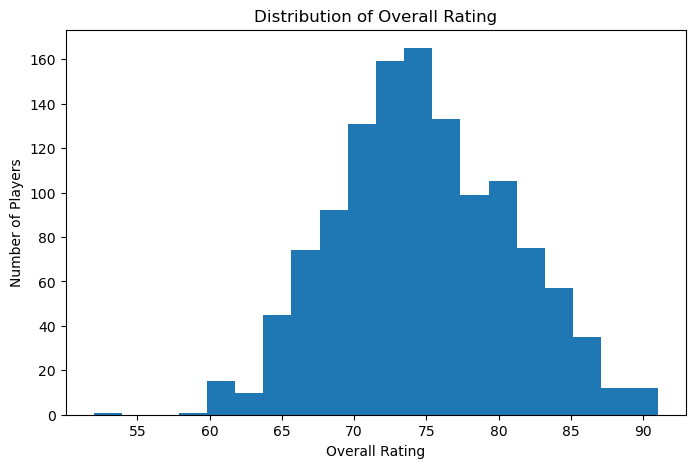

In [ ]:
# Histogram για την κατανομή του overall rating

plt.figure(figsize=(8, 5))

plt.hist(df['overall'], bins=20)

plt.title('Distribution of Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')

plt.show()

<Figure size 1200x600 with 0 Axes>

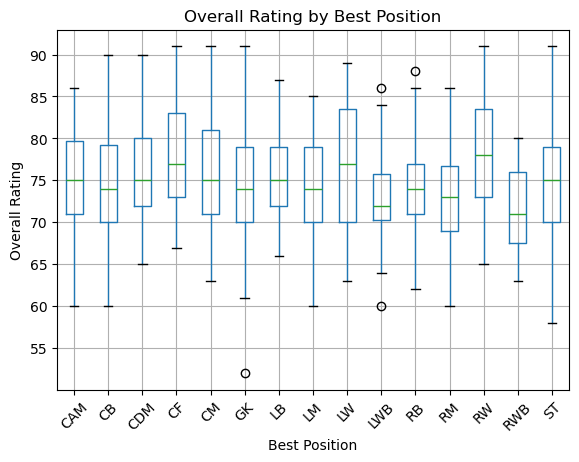

In [46]:
# Boxplot για να δούμε πώς αλλάζει το overall rating ανά θέση

plt.figure(figsize=(12, 6))

df.boxplot(column='overall', by='best_position', rot=45)

plt.title('Overall Rating by Best Position')
plt.suptitle('')
plt.xlabel('Best Position')
plt.ylabel('Overall Rating')

plt.show()

In [38]:
# Βλέπουμε τον μέσο όρο βασικών χαρακτηριστικών ανά θέση

key_attributes = [
    'pace_total',
    'shooting_total',
    'passing_total',
    'dribbling_total',
    'defending_total',
    'physicality_total'
]

attributes_by_position = df.groupby('best_position')[key_attributes].mean()

attributes_by_position

,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
best_position,,,,,,
CAM,75.422535,70.859155,73.014085,77.626761,50.514085,64.394366
CB,65.262712,43.368644,58.046610,60.504237,74.872881,77.521186
CDM,64.610526,60.863158,70.368421,71.157895,73.526316,75.926316
CF,78.176471,77.058824,72.941176,79.294118,39.588235,70.058824
CM,68.130841,67.934579,74.308411,75.000000,68.495327,72.672897
GK,74.881119,71.615385,70.013986,76.503497,42.734266,73.643357
LB,77.560976,58.024390,69.951220,72.243902,71.756098,71.780488
LM,82.173077,68.865385,69.038462,75.134615,47.826923,65.769231
LW,82.130435,72.565217,72.000000,79.347826,40.304348,62.695652


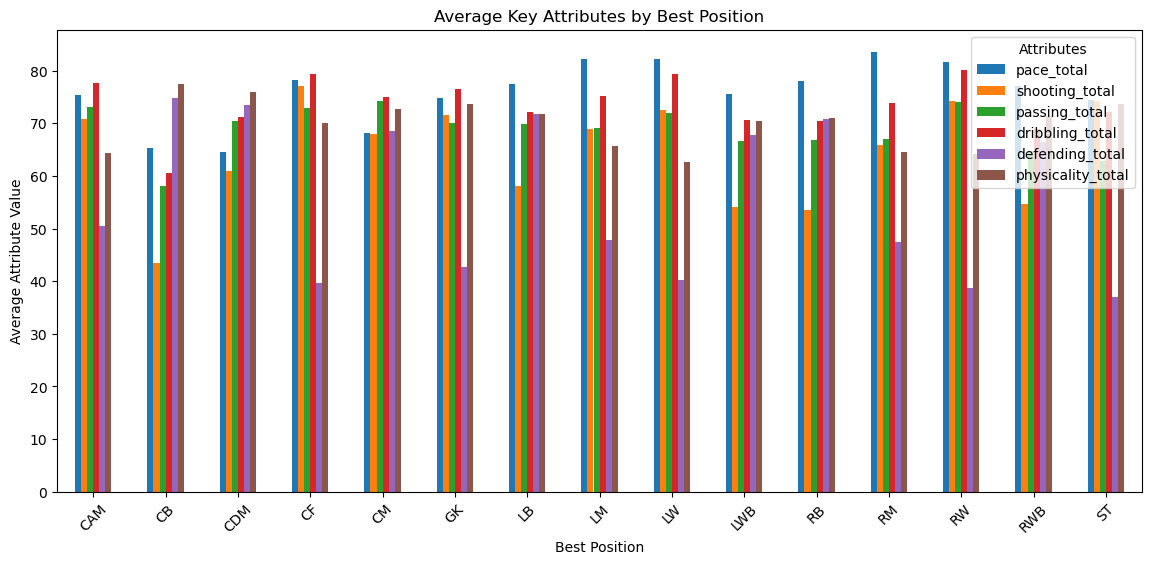

In [ ]:
# Bar Chart για τα βασικά χαρακτηριστικά ανά θέση

attributes_by_position.plot(kind='bar', figsize=(14, 6))

plt.title('Average Key Attributes by Best Position')
plt.xlabel('Best Position')
plt.ylabel('Average Attribute Value')

plt.xticks(rotation=45)
plt.legend(title='Attributes')

plt.show()

In [40]:
# Ελέγχουμε τη συσχέτιση μεταξύ βασικών αριθμητικών χαρακτηριστικών

correlation_features = [
    'age',
    'overall',
    'potential',
    'pace_total',
    'shooting_total',
    'passing_total',
    'dribbling_total',
    'defending_total',
    'physicality_total'
]

correlation_matrix = df[correlation_features].corr()

correlation_matrix

,age,overall,potential,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
age,1.000000,0.168454,-0.326898,-0.261716,0.150692,0.161267,0.035697,0.082595,0.227835
overall,0.168454,1.000000,0.823943,0.250153,0.434939,0.674052,0.653063,0.231486,0.414980
potential,-0.326898,0.823943,1.000000,0.333027,0.308442,0.523091,0.569117,0.154658,0.247106
pace_total,-0.261716,0.250153,0.333027,1.000000,0.355287,0.265859,0.511084,-0.305727,-0.127021
shooting_total,0.150692,0.434939,0.308442,0.355287,1.000000,0.682142,0.793318,-0.494224,-0.042532
passing_total,0.161267,0.674052,0.523091,0.265859,0.682142,1.000000,0.841863,0.032075,0.043816
dribbling_total,0.035697,0.653063,0.569117,0.511084,0.793318,0.841863,1.000000,-0.259190,-0.058529
defending_total,0.082595,0.231486,0.154658,-0.305727,-0.494224,0.032075,-0.259190,1.000000,0.448219
physicality_total,0.227835,0.414980,0.247106,-0.127021,-0.042532,0.043816,-0.058529,0.448219,1.000000


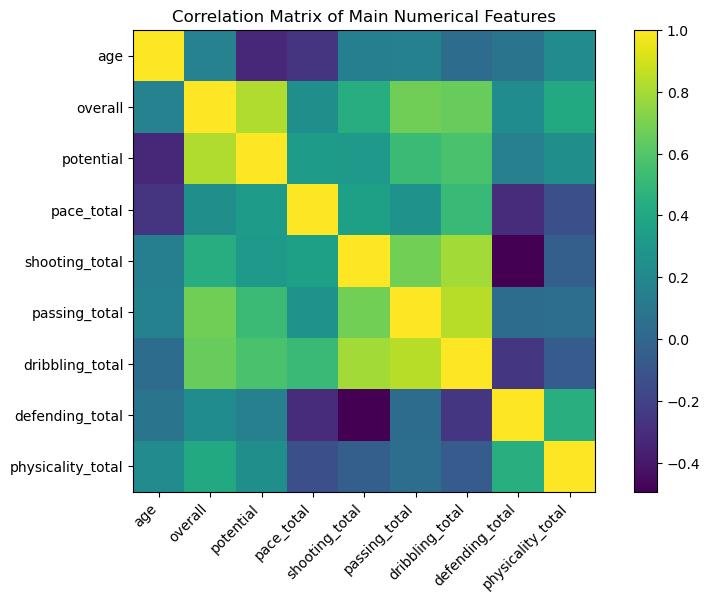

In [ ]:
# Correlation Matrix βασικών χαρακτηριστικών

plt.figure(figsize=(10, 6))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(range(len(correlation_features)), correlation_features, rotation=45, ha='right')
plt.yticks(range(len(correlation_features)), correlation_features)

plt.title('Correlation Matrix of Main Numerical Features')

plt.show()

## 4. Descriptive Statistics

Σε αυτό το βήμα βλέπουμε βασικά στατιστικά στοιχεία για τους παίκτες, όπως μέσο όρο, ελάχιστη και μέγιστη τιμή.

Αυτό μας βοηθά να καταλάβουμε καλύτερα τα χαρακτηριστικά του dataset πριν προχωρήσουμε στην προεπεξεργασία και στα μοντέλα ταξινόμησης.

In [75]:
# Περιγραφικά στατιστικά για όλες τις αριθμητικές στήλες
df.describe()

,id,age,height,weight,overall,potential,growth,total_stats,base_stats,national_number,...,lm_rating,cm_rating,rm_rating,lwb_rating,cdm_rating,rwb_rating,lb_rating,cb_rating,rb_rating,gk_rating
count,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,...,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000,1221.000000
mean,224937.543817,26.741196,182.755938,76.394758,74.873874,77.989353,3.115479,1803.846028,404.081081,13.549550,...,66.396396,65.982801,66.396396,63.722359,63.900901,63.722359,62.855856,61.497952,62.855856,25.796069
std,26273.298927,4.152840,6.746296,7.288759,6.192577,6.359894,3.727690,283.791107,36.181022,7.528321,...,15.172995,14.115584,15.172995,15.120090,14.970600,15.120090,15.405573,16.140958,15.405573,18.235936
min,20801.000000,17.000000,163.000000,58.000000,52.000000,55.000000,0.000000,927.000000,298.000000,1.000000,...,21.000000,22.000000,21.000000,19.000000,22.000000,19.000000,19.000000,21.000000,19.000000,13.000000
25%,208418.000000,24.000000,178.000000,71.000000,71.000000,74.000000,0.000000,1678.000000,381.000000,7.000000,...,63.000000,62.000000,63.000000,59.000000,58.000000,59.000000,56.000000,52.000000,56.000000,18.000000
50%,229261.000000,27.000000,183.000000,76.000000,75.000000,78.000000,2.000000,1867.000000,406.000000,14.000000,...,70.000000,69.000000,70.000000,68.000000,68.000000,68.000000,67.000000,66.000000,67.000000,20.000000
75%,242541.000000,30.000000,188.000000,81.000000,79.000000,83.000000,5.000000,1999.000000,429.000000,20.000000,...,76.000000,75.000000,76.000000,74.000000,74.000000,74.000000,73.000000,74.000000,73.000000,21.000000
max,272569.000000,40.000000,203.000000,102.000000,91.000000,95.000000,22.000000,2317.000000,502.000000,30.000000,...,92.000000,91.000000,92.000000,88.000000,90.000000,88.000000,87.000000,90.000000,87.000000,91.000000


In [76]:
# Βλέπουμε τους τύπους δεδομένων κάθε στήλης
df.dtypes

id             int64
name          object
full_name     object
age            int64
height         int64
               ...  
rwb_rating     int64
lb_rating      int64
cb_rating      int64
rb_rating      int64
gk_rating      int64
Length: 82, dtype: object

In [81]:
# Επιλέγουμε βασικά αριθμητικά χαρακτηριστικά που σχετίζονται με την απόδοση του παίκτη

important_numeric_features = [
    'age',
    'height',
    'weight',
    'overall',
    'potential',
    'growth',
    'pace_total',
    'shooting_total',
    'passing_total',
    'dribbling_total',
    'defending_total',
    'physicality_total'
]

# Βλέπουμε στατιστικά μόνο για αυτές τις στήλες
df[important_numeric_features].describe().round(2)

,age,height,weight,overall,potential,growth,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
count,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00
mean,26.74,182.76,76.39,74.87,77.99,3.12,73.08,62.69,67.14,71.63,57.75,71.79
std,4.15,6.75,7.29,6.19,6.36,3.73,10.59,14.22,9.40,9.05,17.32,8.30
min,17.00,163.00,58.00,52.00,55.00,0.00,30.00,22.00,35.00,39.00,17.00,43.00
25%,24.00,178.00,71.00,71.00,74.00,0.00,67.00,55.00,62.00,67.00,43.00,67.00
50%,27.00,183.00,76.00,75.00,78.00,2.00,74.00,66.00,68.00,72.00,62.00,73.00
75%,30.00,188.00,81.00,79.00,83.00,5.00,81.00,73.00,73.00,78.00,72.00,78.00
max,40.00,203.00,102.00,91.00,95.00,22.00,97.00,92.00,93.00,94.00,91.00,91.00


In [80]:
# Βλέπουμε τον μέσο όρο βασικών χαρακτηριστικών ανά θέση παίκτη

position_stats = df.groupby('best_position')[important_numeric_features].mean()

position_stats.round(2)

,age,height,weight,overall,potential,growth,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
best_position,,,,,,,,,,,,
CAM,24.48,178.61,72.23,75.32,80.54,5.21,75.42,70.86,73.01,77.63,50.51,64.39
CB,26.89,187.13,80.87,74.66,77.88,3.22,65.26,43.37,58.05,60.50,74.87,77.52
CDM,26.89,182.21,74.82,75.93,78.71,2.78,64.61,60.86,70.37,71.16,73.53,75.93
CF,29.00,180.12,75.35,77.94,78.12,0.18,78.18,77.06,72.94,79.29,39.59,70.06
CM,26.64,180.80,73.14,75.89,78.58,2.69,68.13,67.93,74.31,75.00,68.50,72.67
GK,28.94,190.14,83.14,74.65,77.08,2.43,74.88,71.62,70.01,76.50,42.73,73.64
LB,28.51,177.88,72.49,75.80,76.95,1.15,77.56,58.02,69.95,72.24,71.76,71.78
LM,26.19,178.63,72.12,73.96,76.58,2.62,82.17,68.87,69.04,75.13,47.83,65.77
LW,27.74,177.09,70.30,77.17,78.09,0.91,82.13,72.57,72.00,79.35,40.30,62.70
